In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    roc_curve,
    auc,
    RocCurveDisplay,
    accuracy_score,
    ConfusionMatrixDisplay
)

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features.copy()
y = heart_disease.data.targets.copy()
  
# variable information 
print(heart_disease.variables) 


        name     role         type demographic  \
0        age  Feature      Integer         Age   
1        sex  Feature  Categorical         Sex   
2         cp  Feature  Categorical        None   
3   trestbps  Feature      Integer        None   
4       chol  Feature      Integer        None   
5        fbs  Feature  Categorical        None   
6    restecg  Feature  Categorical        None   
7    thalach  Feature      Integer        None   
8      exang  Feature  Categorical        None   
9    oldpeak  Feature      Integer        None   
10     slope  Feature  Categorical        None   
11        ca  Feature      Integer        None   
12      thal  Feature  Categorical        None   
13       num   Target      Integer        None   

                                          description  units missing_values  
0                                                None  years             no  
1                                                None   None             no  
2              

In [3]:
X.head()      

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [4]:
X.info()     
X.describe() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [5]:
y.info()     
y.describe() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   num     303 non-null    int64
dtypes: int64(1)
memory usage: 2.5 KB


,num
count,303.000000
mean,0.937294
std,1.228536
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,4.000000


## Identify categorical/binary features

In [6]:
y['num'].unique()

array([0, 2, 1, 3, 4])

In [7]:
X['ca'].unique()

array([ 0.,  3.,  2.,  1., nan])

In [8]:
X['thal'].unique()

array([ 6.,  3.,  7., nan])

In [9]:
X['slope'].unique()

array([3, 2, 1])

In [10]:
X['restecg'].unique()

array([2, 0, 1])

In [11]:
X['sex'].unique()

array([1, 0])

In [12]:
X['exang'].unique()

array([0, 1])

In [13]:
## Check number of missing rows
X[['ca', 'thal']].isnull().sum()

ca      4
thal    2
dtype: int64

## Drop Missing Rows:
Since there are only a few rows containing missing values, it is okay to drop them to avoid making assuptions in medical data.

In [14]:
X = X.dropna(subset=['ca', 'thal'])

In [15]:
X.head()      
X.info()     
X.describe() 

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    int64  
 1   sex       297 non-null    int64  
 2   cp        297 non-null    int64  
 3   trestbps  297 non-null    int64  
 4   chol      297 non-null    int64  
 5   fbs       297 non-null    int64  
 6   restecg   297 non-null    int64  
 7   thalach   297 non-null    int64  
 8   exang     297 non-null    int64  
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    int64  
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 32.5 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


#### Num: diagnosis of heart disease
- numbered as 0, 1, 2, 3, or 4
- 0 = no heart disease
- 1 - 4 = has heart disease
    - 1 = mild
    - 2 = moderate
    - 3 = severe
    - 4 = very severe

For plotting, we will simplify this as:
- 0 = no heart disease
- 1 = heart disease present

In [16]:
## Combine features (X) and target (y)
df = X.copy()
df['num'] = y

In [17]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')


In [18]:
## Change num to either 0 (disease negative) or 1 (disease positive)
df['num_binary'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

In [19]:
y = df['num_binary']
X = df.drop(columns=['num', 'num_binary'])

In [20]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'num_binary'],
      dtype='object')


In [21]:
## Color palette
palette = {0: "#568BCB", 1: "#9E1B1B"}

In [22]:
# Color palette for Heatmap
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list(
    "custom_red",
    ["#568BCB", "#FFE0E0", "#9E1B1B"]
)

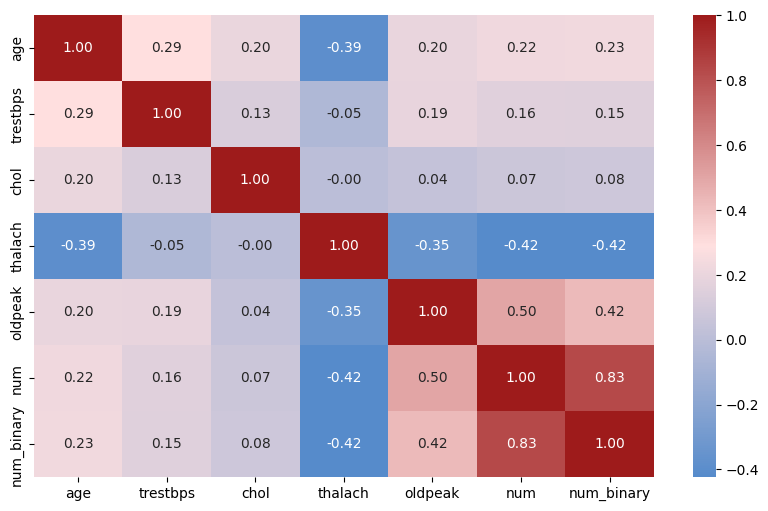

In [23]:
## Plot Heatmap with numerical features and target)
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'num', 'num_binary']
corr = df[num_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap = cmap, fmt=".2f")
plt.show()

# Numerical Features with highest correlation with target:

### Strong features
- oldpeak (0.50): Difference in the ST segment level between rest and exercise (how well does the heart handle stress)

### Moderate features
- thalach (-0.42): Indicates max heart rate (lower the rate, higher the chance of having heart disease)

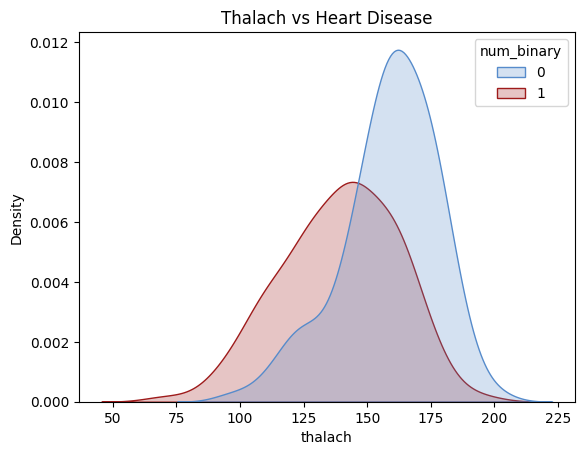

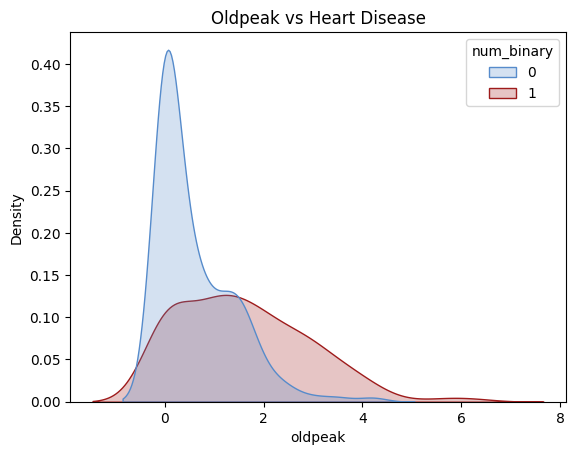

In [24]:
### Highest correlated features grouped by num_binary (continuous features)

# thalach & num
sns.kdeplot(data=df, x='thalach', hue='num_binary',palette=palette, fill=True)
plt.title("Thalach vs Heart Disease")
plt.show()

# oldpeak & num
sns.kdeplot(data=df, x='oldpeak', hue='num_binary', palette=palette, fill=True)
plt.title("Oldpeak vs Heart Disease")
plt.show()

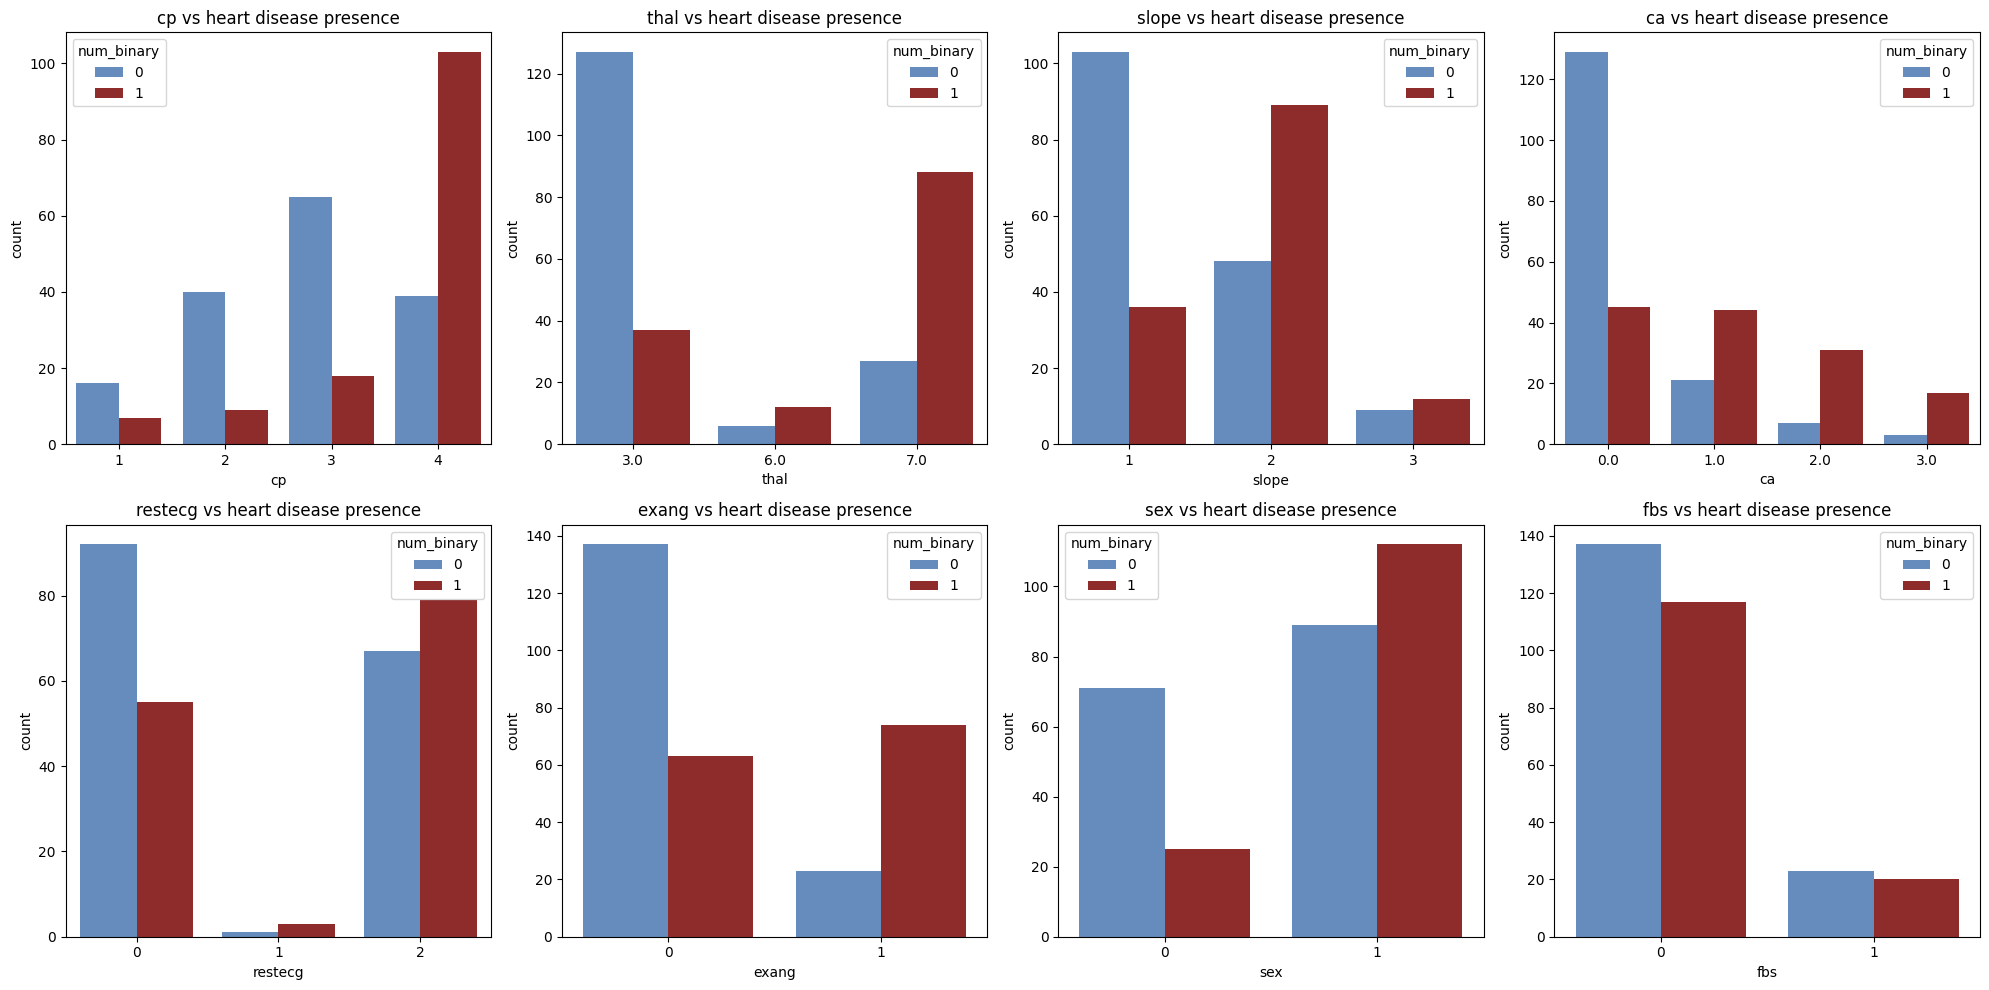

In [25]:
### Categorical features grouped by num_binary (discrete features)

categorical_features = ['cp','thal','slope','ca','restecg','exang','sex','fbs']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(data=df, x=col, hue='num_binary',palette=palette, ax=axes[i])
    axes[i].set_title(f"{col} vs heart disease presence")

plt.tight_layout()
plt.show()


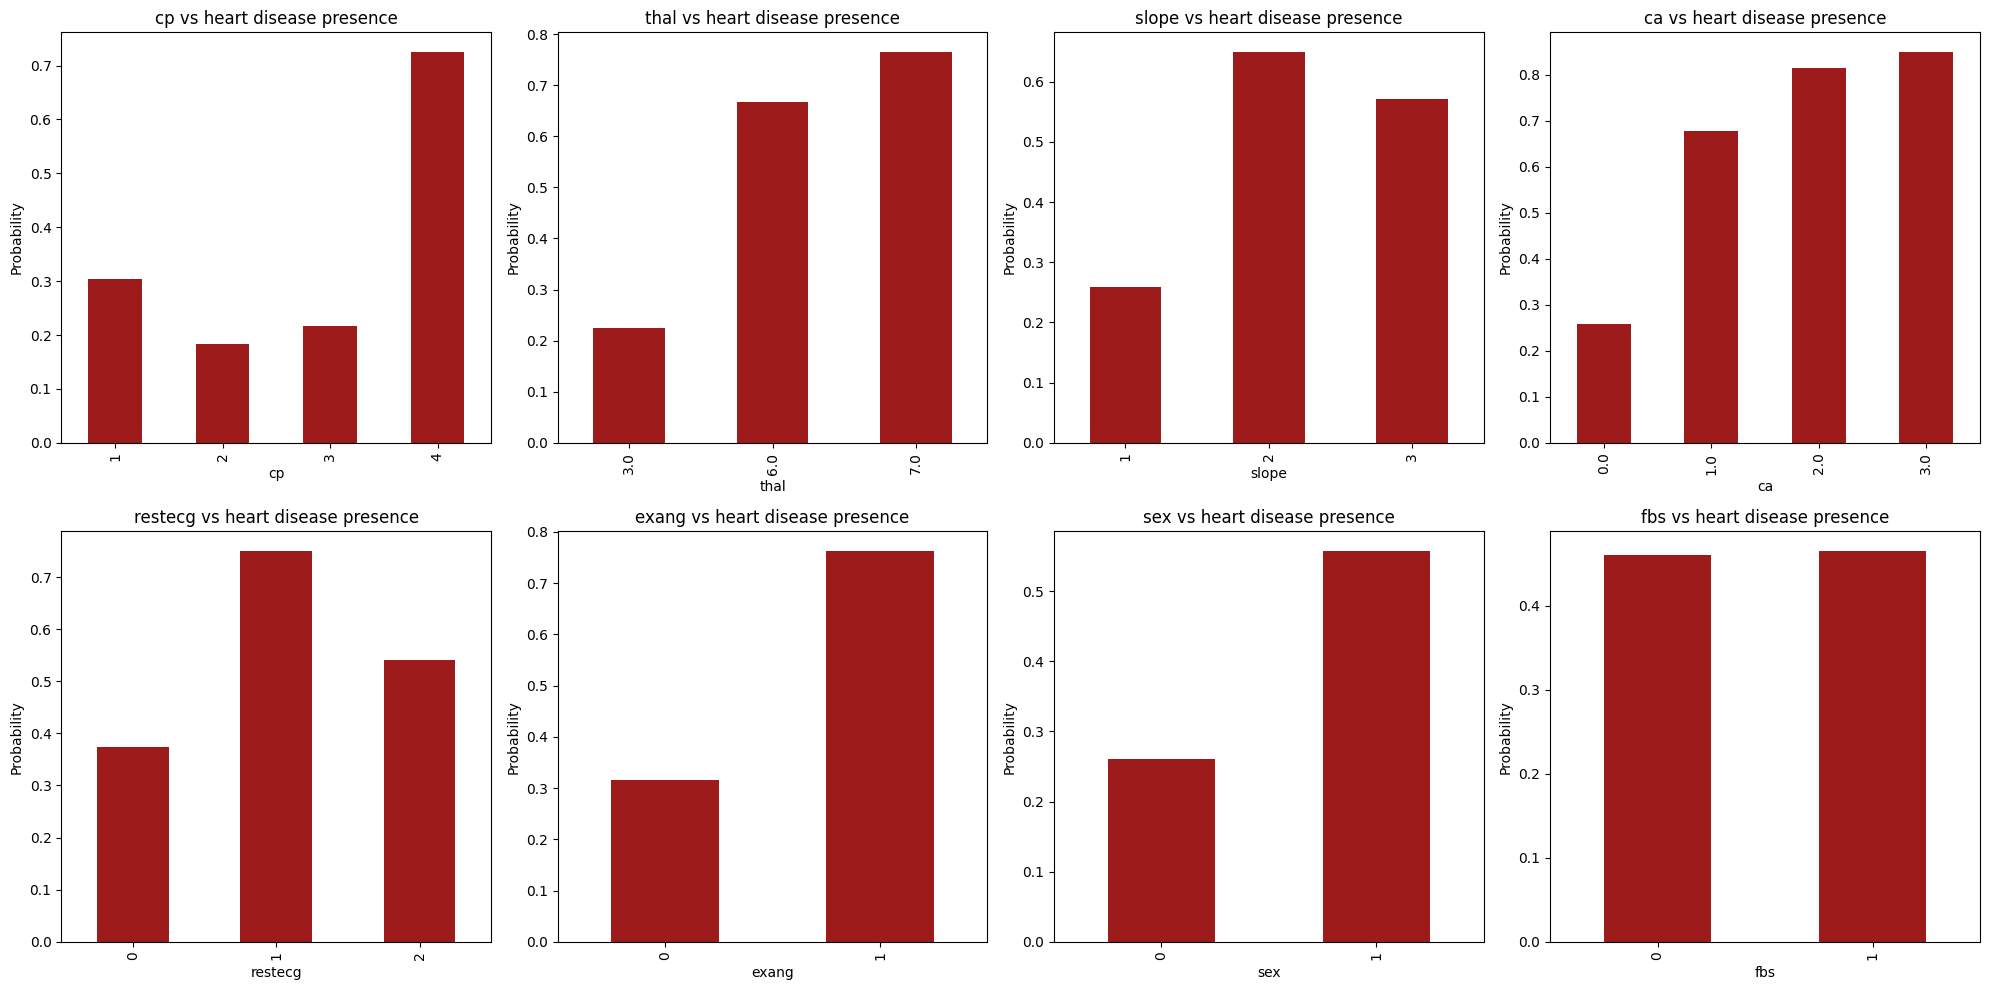

In [26]:
### Categorical features grouped by num_binary using probability (discrete features)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    
    probs = df.groupby(col)['num_binary'].mean()
    
    probs.plot(kind='bar', color = "#9E1B1B", ax=axes[i])
    axes[i].set_title(f"{col} vs heart disease presence")
    axes[i].set_ylabel("Probability")

plt.tight_layout()
plt.show()

In [27]:
## Difference in probability between presence and absence of heart disease
results = []

for col in categorical_features:
    probs = df.groupby(col)['num_binary'].mean()

    diff = probs.max() - probs.min()
    results.append((col, diff))

results_df = pd.DataFrame(results, columns=['feature', 'prob_diff'])
results_df = results_df.sort_values('prob_diff', ascending=False)
results_df

,feature,prob_diff
3,ca,0.591379
0,cp,0.541679
1,thal,0.539608
5,exang,0.447887
2,slope,0.390642
4,restecg,0.375850
6,sex,0.296797
7,fbs,0.004486


In [28]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'num_binary'],
      dtype='object')


# Considerable Categorical Features from Probability Difference:
### Strong features
- ca (0.591): Indicates number of blocked blood vessels 
- cp (0.541): Chest pain type from 0-4
- thal (0.539): Measuring blood flow to the heart (3 = nomal, 6 = fixed defect, 7 = reversable defect)

### Moderate features
- exang (0.448): Exercise induced angina
- slope(0.391): ST slope during exercise ECG
- restecg (0.376): Resting ECG results

# Preprocessing

In [29]:
# Splitting X and target (full range and binary)
target = df['num']
target_binary = df['num_binary']
df = df.drop(columns=['num', 'num_binary'])

In [30]:
# Train test splitting on two sets

seed = 42
test_size = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    df, target,
    random_state=seed,
    test_size=test_size,
    stratify=target
)

X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(
    df, target_binary,
    random_state=seed,
    test_size=test_size,
    stratify=target_binary
)

In [31]:
# Preprocessing method

def preprocess(X_train, X_test):
    norm_vars = ['age', 'trestbps', 'chol', 'thalach']
    categorical_features = ['cp', 'thal', 'slope', 'ca', 'restecg', 'exang', 'sex', 'fbs']
    category_map = {category: 'category' for category in categorical_features}
    scaler = StandardScaler()

    X_train[norm_vars] = scaler.fit_transform(X_train[norm_vars])
    X_test[norm_vars] = scaler.fit_transform(X_test[norm_vars])

    X_train['oldpeak'] = np.log(X_train['oldpeak'] + 1)
    X_test['oldpeak'] = np.log(X_test['oldpeak'] + 1)


    X_train[categorical_features] = X_train[categorical_features].astype(category_map)
    X_test[categorical_features] = X_test[categorical_features].astype(category_map)

    X_train = pd.get_dummies(X_train, dtype=int)
    X_test = pd.get_dummies(X_test, dtype=int)

    return X_train, X_test

In [32]:
X_train, X_test = preprocess(X_train, X_test)
X_train_binary, X_test_binary = preprocess(X_train_binary, X_test_binary)

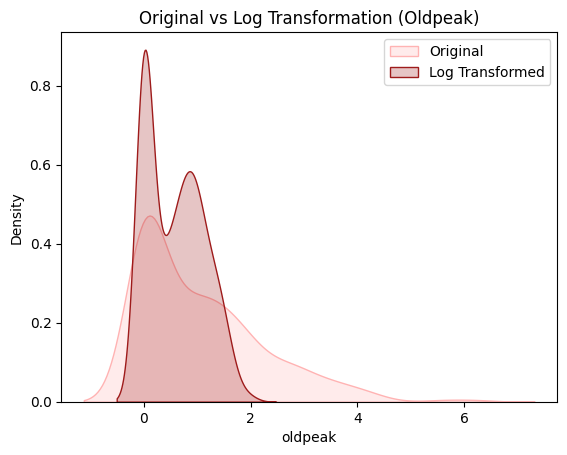

In [33]:
sns.kdeplot(df['oldpeak'], label="Original", color="#FFB3B3", fill=True)
sns.kdeplot(np.log1p(df['oldpeak']), label="Log Transformed", color="#9E1B1B", fill=True)

plt.title("Original vs Log Transformation (Oldpeak)")
plt.legend()
plt.show()

# Baseline for Machine Learning
Since simply guessing every patient has a status of 0 achieves an accuracy of 0.53, we will use that as a baseline of comparison in our model building.

In [34]:
y_test_binary_baseline = np.zeros(len(y_test_binary))

In [35]:
accuracy_score(y_test_binary, y_test_binary_baseline)

0.5333333333333333

In [36]:
# Logistic regression standard y

lr = LogisticRegression()
lr.fit(X_train, y_train)

lr.score(X_test, y_test)

0.6

In [37]:
# Logistic regression binary y

lr_binary = LogisticRegression()
lr_binary.fit(X_train_binary, y_train_binary)

lr_binary.score(X_test_binary, y_test_binary)

0.85

## Decision Tree

In [38]:
# Decision tree standard y

tree = DecisionTreeClassifier(max_depth=20)
tree.fit(X_train, y_train)

tree.score(X_test, y_test)

0.48333333333333334

In [39]:
# Decision tree binary y

tree_binary = DecisionTreeClassifier(max_depth=20)
tree_binary.fit(X_train_binary, y_train_binary)

tree_binary.score(X_test_binary, y_test_binary)


0.7

## Random Forest

In [40]:
# Random forest standard y

forest = RandomForestClassifier()
forest.fit(X_train, y_train)

forest.score(X_test, y_test)

0.5333333333333333

In [41]:
# Random forest binary y

forest_binary = RandomForestClassifier()
forest_binary.fit(X_train_binary, y_train_binary)

forest_binary.score(X_test_binary, y_test_binary)

0.85

## SVC

In [42]:
# SVC standard y

svc = SVC()
svc.fit(X_train, y_train)

svc.score(X_test, y_test)

0.5666666666666667

In [43]:
# SVC binary y

svc_binary = SVC()
svc_binary.fit(X_train_binary, y_train_binary)

svc_binary.score(X_test_binary, y_test_binary)


0.8666666666666667

# Model Evaluation

## Classification Reports

In [44]:
estimator_names = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVC']
estimators = [lr, tree, forest, svc]
estimators_binary = [lr_binary, tree_binary, forest_binary, svc_binary]

# Displaying precision, recall, and f1 for all models using full range of target values
# All models had classes which predicted zero for certain classes of target column,
# handled with zero_division parameter
for i, estimator in enumerate(estimators):
    report = classification_report(
        y_test, estimator.predict(X_test),
        output_dict=True,
        zero_division=0
    )
    df_report = pd.DataFrame(report).transpose()

    print(f'{estimator_names[i]} Classification Report')
    display(HTML(df_report.to_html(classes='table table-striped')))

Logistic Regression Classification Report


,precision,recall,f1-score,support
0,0.810811,0.937500,0.869565,32.0
1,0.375000,0.272727,0.315789,11.0
2,0.000000,0.000000,0.000000,7.0
3,0.375000,0.428571,0.400000,7.0
4,0.000000,0.000000,0.000000,3.0
accuracy,0.600000,0.600000,0.600000,0.6
macro avg,0.312162,0.327760,0.317071,60.0
weighted avg,0.544932,0.600000,0.568330,60.0


Decision Tree Classification Report


,precision,recall,f1-score,support
0,0.814815,0.687500,0.745763,32.000000
1,0.266667,0.363636,0.307692,11.000000
2,0.500000,0.428571,0.461538,7.000000
3,0.000000,0.000000,0.000000,7.000000
4,0.000000,0.000000,0.000000,3.000000
accuracy,0.483333,0.483333,0.483333,0.483333
macro avg,0.316296,0.295942,0.302999,60.000000
weighted avg,0.541790,0.483333,0.507997,60.000000


Random Forest Classification Report


,precision,recall,f1-score,support
0,0.756098,0.968750,0.849315,32.000000
1,0.125000,0.090909,0.105263,11.000000
2,0.000000,0.000000,0.000000,7.000000
3,0.000000,0.000000,0.000000,7.000000
4,0.000000,0.000000,0.000000,3.000000
accuracy,0.533333,0.533333,0.533333,0.533333
macro avg,0.176220,0.211932,0.190916,60.000000
weighted avg,0.426169,0.533333,0.472266,60.000000


SVC Classification Report


,precision,recall,f1-score,support
0,0.744186,1.000000,0.853333,32.000000
1,0.142857,0.090909,0.111111,11.000000
2,0.142857,0.142857,0.142857,7.000000
3,0.000000,0.000000,0.000000,7.000000
4,0.000000,0.000000,0.000000,3.000000
accuracy,0.566667,0.566667,0.566667,0.566667
macro avg,0.205980,0.246753,0.221460,60.000000
weighted avg,0.439756,0.566667,0.492148,60.000000


## Confusion Matrices

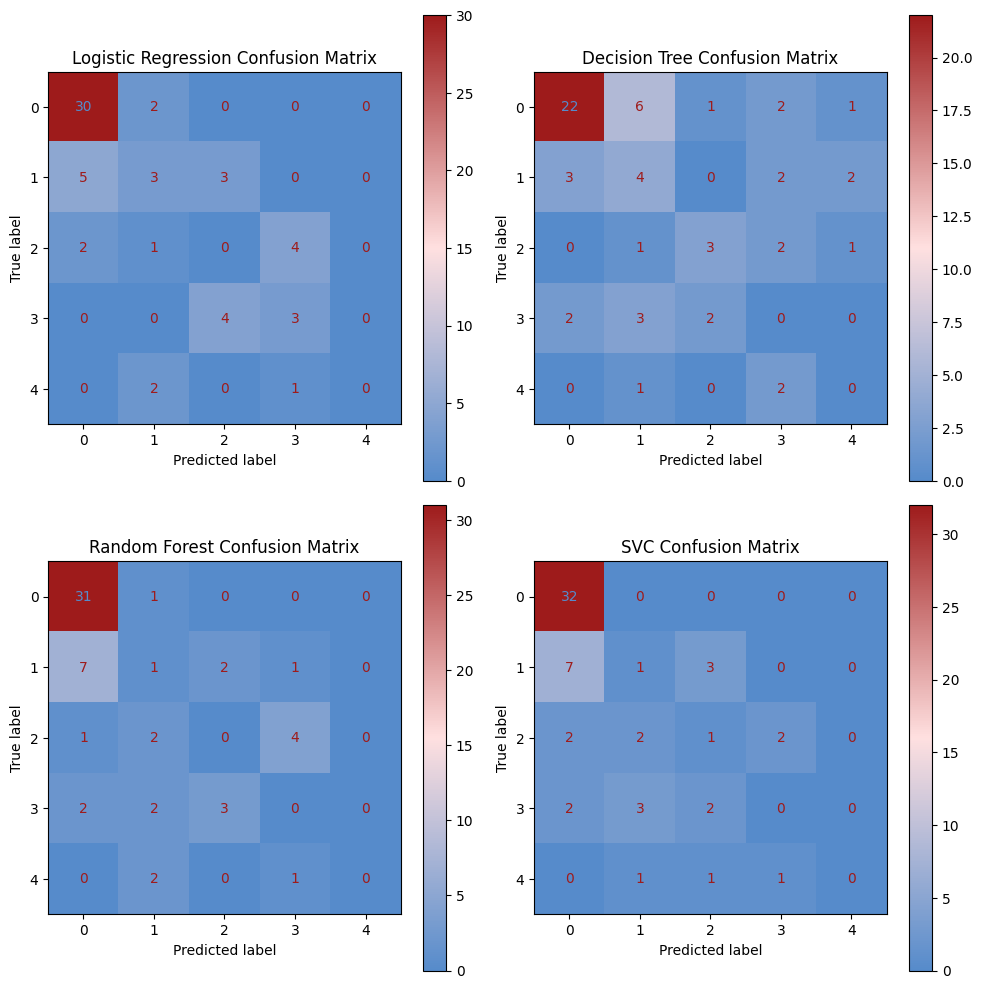

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i, estimator in enumerate(estimators):
    ConfusionMatrixDisplay.from_estimator(estimator, X_test, y_test, ax=axes[i], cmap=cmap)
    axes[i].set_title(f"{estimator_names[i]} Confusion Matrix")

plt.tight_layout()
plt.show()

# Binary Model Evaluation

# ROC AUC Curves
Binary models used since only binary classification is supported

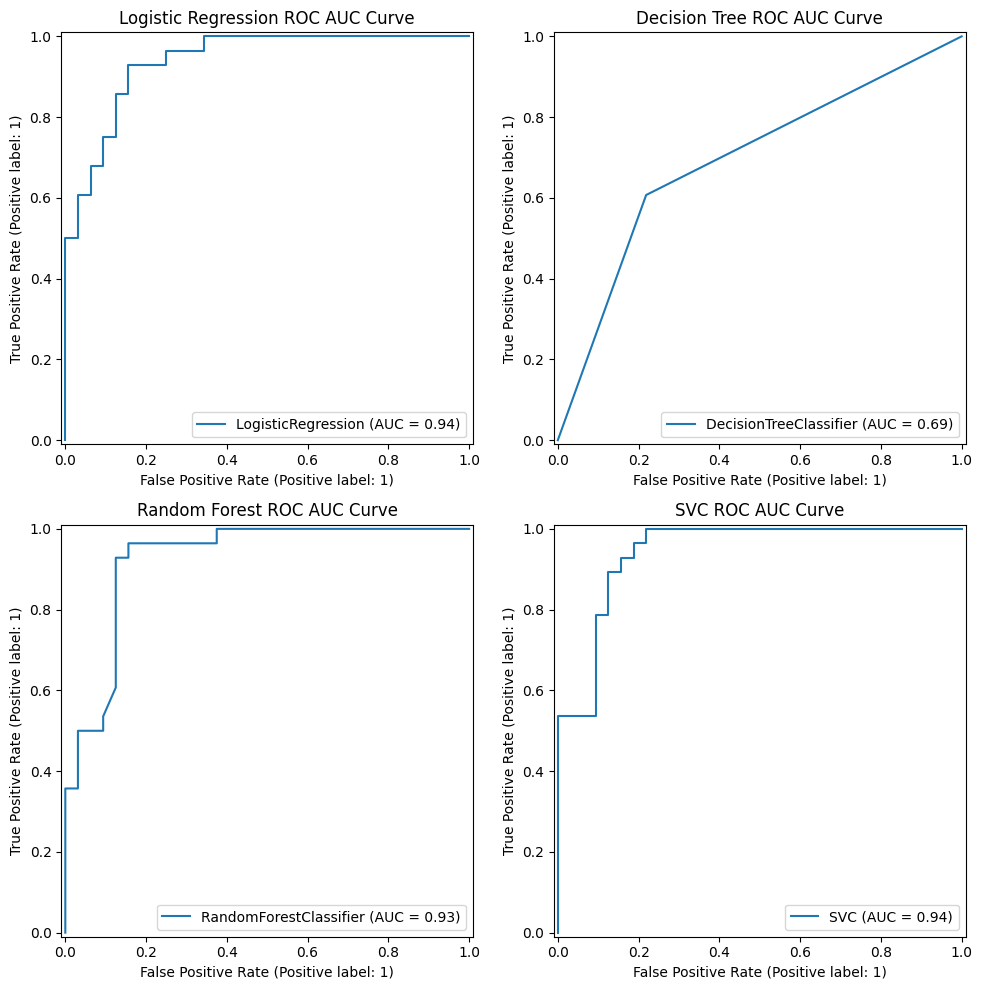

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i, estimator in enumerate(estimators_binary):
    RocCurveDisplay.from_estimator(estimator, X_test_binary, y_test_binary, ax=axes[i])
    axes[i].set_title(f"{estimator_names[i]} ROC AUC Curve")

plt.tight_layout()
plt.show()

## Binary Classification Reports

In [47]:
for i, estimator in enumerate(estimators_binary):
    report = classification_report(
        y_test_binary, estimator.predict(X_test_binary),
        output_dict=True,
        zero_division=0
    )
    df_report = pd.DataFrame(report).transpose()

    print(f'{estimator_names[i]} Classification Report - Binary Models')
    display(HTML(df_report.to_html(classes='table table-striped')))

Logistic Regression Classification Report - Binary Models


,precision,recall,f1-score,support
0,0.848485,0.875000,0.861538,32.00
1,0.851852,0.821429,0.836364,28.00
accuracy,0.850000,0.850000,0.850000,0.85
macro avg,0.850168,0.848214,0.848951,60.00
weighted avg,0.850056,0.850000,0.849790,60.00


Decision Tree Classification Report - Binary Models


,precision,recall,f1-score,support
0,0.694444,0.781250,0.735294,32.0
1,0.708333,0.607143,0.653846,28.0
accuracy,0.700000,0.700000,0.700000,0.7
macro avg,0.701389,0.694196,0.694570,60.0
weighted avg,0.700926,0.700000,0.697285,60.0


Random Forest Classification Report - Binary Models


,precision,recall,f1-score,support
0,0.848485,0.875000,0.861538,32.00
1,0.851852,0.821429,0.836364,28.00
accuracy,0.850000,0.850000,0.850000,0.85
macro avg,0.850168,0.848214,0.848951,60.00
weighted avg,0.850056,0.850000,0.849790,60.00


SVC Classification Report - Binary Models


,precision,recall,f1-score,support
0,0.875000,0.875000,0.875000,32.000000
1,0.857143,0.857143,0.857143,28.000000
accuracy,0.866667,0.866667,0.866667,0.866667
macro avg,0.866071,0.866071,0.866071,60.000000
weighted avg,0.866667,0.866667,0.866667,60.000000


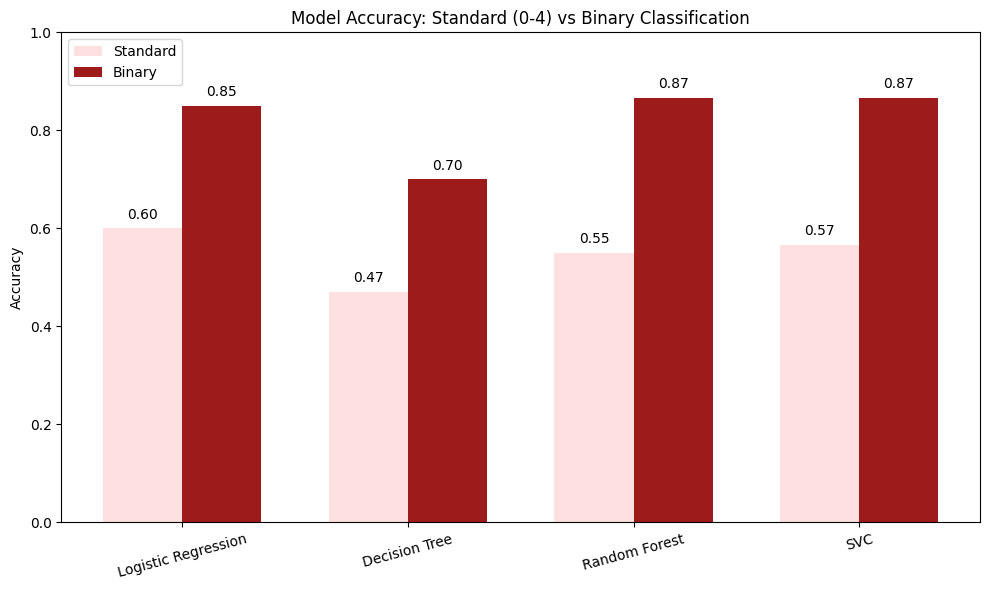

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Model names
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVC']

# Multiclass accuracies
multiclass_acc = [0.60, 0.47, 0.55, 0.5667]

# Binary accuracies
binary_acc = [0.85, 0.70, 0.8667, 0.8667]

# X-axis positions
x = np.arange(len(models))
width = 0.35

# Create plot
plt.figure(figsize=(10, 6))

# Bars
plt.bar(x - width/2, multiclass_acc, width, label='Standard', color="#FFE0E0")
plt.bar(x + width/2, binary_acc, width, label='Binary', color="#9E1B1B")

# Labels and formatting
plt.xticks(x, models, rotation=15)
plt.ylabel("Accuracy")
plt.title("Model Accuracy: Standard (0-4) vs Binary Classification")
plt.ylim(0, 1)
plt.legend()

# Add value labels on top of bars
for i in range(len(models)):
    plt.text(x[i] - width/2, multiclass_acc[i] + 0.02, f"{multiclass_acc[i]:.2f}", ha='center')
    plt.text(x[i] + width/2, binary_acc[i] + 0.02, f"{binary_acc[i]:.2f}", ha='center')

plt.tight_layout()
plt.show()

## Binary Confusion Matrices

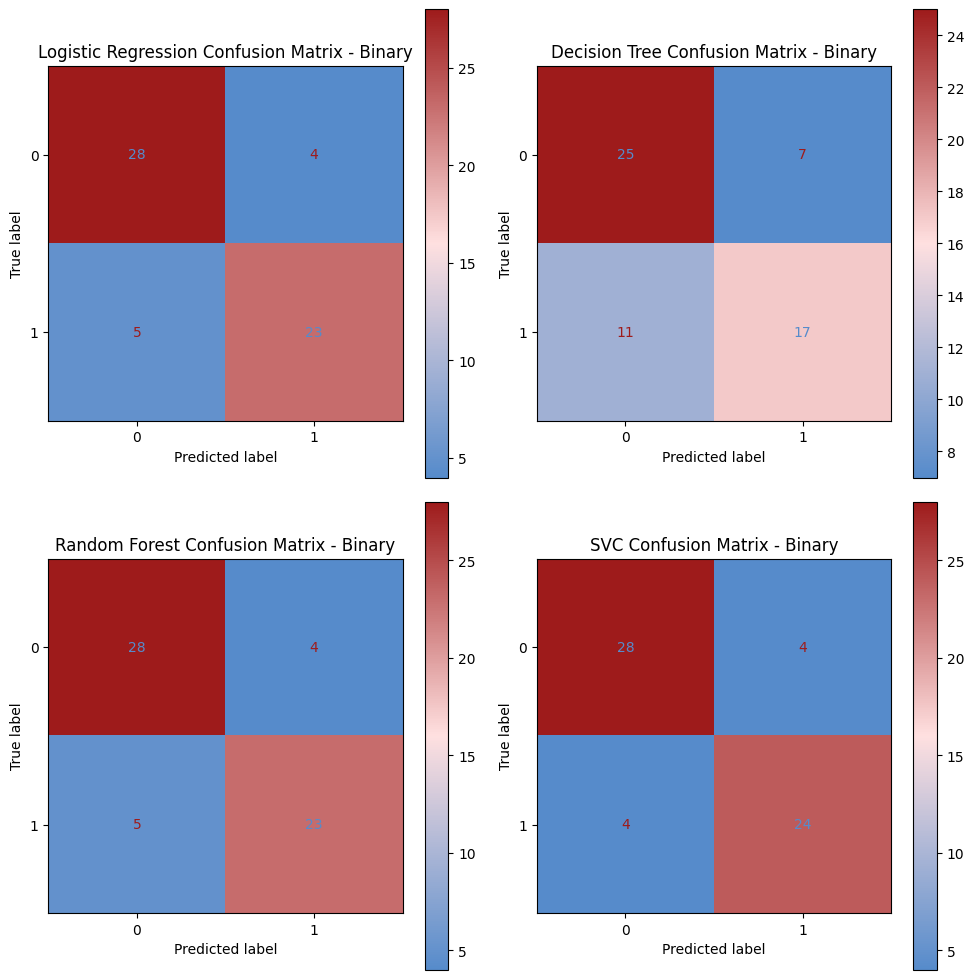

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i, estimator in enumerate(estimators_binary):
    ConfusionMatrixDisplay.from_estimator(estimator, X_test_binary, y_test_binary, ax=axes[i], cmap=cmap)
    axes[i].set_title(f"{estimator_names[i]} Confusion Matrix - Binary")

plt.tight_layout()
plt.show()

# Hyperparameter Tuning
We can implement the GridSearchCV class to systematically find the optimal parameters to produce the best possible results. Using the built in get_params and get_score methods we can see the optimal parameters and best score acheived across the 5 cross validation folds.

In [50]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_tree = GridSearchCV(tree, param_grid=param_grid, cv=5)
grid_tree.fit(X_train, y_train)

print('Decision Tree:')
print(grid_tree.best_params_)
print(grid_tree.best_score_)

grid_tree_binary = GridSearchCV(tree_binary, param_grid=param_grid, cv=5)
grid_tree_binary.fit(X_train_binary, y_train_binary)


print('Decision Tree - Binary:')
print(grid_tree_binary.best_params_)
print(grid_tree_binary.best_score_)


Decision Tree:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
0.5655141843971631
Decision Tree - Binary:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
0.8053191489361702


In [51]:
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30]
}

grid_forest = GridSearchCV(forest, param_grid=param_grid, cv=5)
grid_forest.fit(X_train, y_train)

print('Random Forest:')
print(grid_forest.best_params_)
print(grid_forest.best_score_)

grid_forest_binary = GridSearchCV(forest_binary, param_grid=param_grid, cv=5)
grid_forest_binary.fit(X_train_binary, y_train_binary)


print('Random Forest - Binary:')
print(grid_forest_binary.best_params_)
print(grid_forest_binary.best_score_)

Random Forest:
{'max_depth': None, 'n_estimators': 200}
0.5824468085106383
Random Forest - Binary:
{'max_depth': 30, 'n_estimators': 100}
0.8179078014184397


In [52]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear', 'poly']
}

grid_svc = GridSearchCV(svc, param_grid=param_grid, cv=5)
grid_svc.fit(X_train, y_train)

print('SVC:')
print(grid_svc.best_params_)
print(grid_svc.best_score_)

grid_svc_binary = GridSearchCV(svc_binary, param_grid=param_grid, cv=5)
grid_svc_binary.fit(X_train_binary, y_train_binary)


print('SVC - Binary:')
print(grid_svc_binary.best_params_)
print(grid_svc_binary.best_score_)

SVC:
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
0.6075354609929077
SVC - Binary:
{'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
0.8430851063829786


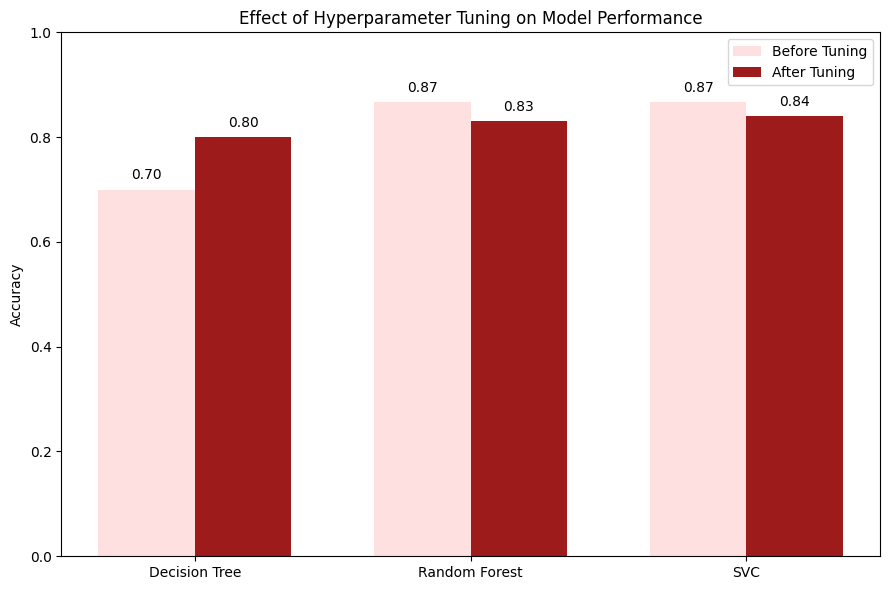

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Models that were actually tuned
models = ['Decision Tree', 'Random Forest', 'SVC']

# BEFORE tuning (your original test accuracies)
before = [0.70, 0.8667, 0.8667]

# AFTER tuning (best CV or test results you reported)
after = [0.80, 0.83, 0.84]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9,6))

# Bars
plt.bar(x - width/2, before, width, label='Before Tuning', color="#FFE0E0")
plt.bar(x + width/2, after, width, label='After Tuning', color="#9E1B1B")

# Labels
plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Effect of Hyperparameter Tuning on Model Performance")
plt.ylim(0, 1)
plt.legend()

# Value labels
for i in range(len(models)):
    plt.text(x[i] - width/2, before[i] + 0.02, f"{before[i]:.2f}", ha='center')
    plt.text(x[i] + width/2, after[i] + 0.02, f"{after[i]:.2f}", ha='center')

plt.tight_layout()
plt.show()